# 03｜CLIP ViT-B/16 基準模型

讀取 02 的 `face_manifest.csv`，訓練 Real／Fake 二元分類的基準模型。

設定：

- CLIP ViT-B/16 視覺主幹**完全凍結**，只訓練上層的 LayerNorm 加線性分類頭。可訓練參數 2,050 個，佔總參數的 0.0014%。
- 使用 01 建立的官方影片切分，不重新隨機分割。
- 同時輸出 frame-level 與 video-level 指標。video-level 為同一部影片 16 幀機率的平均。
- 最佳權重只依**驗證集** video-level AUC 選取，測試集不參與選模。

這個基準的作用是量測「凍結 CLIP 的最終輸出特徵本身含有多少偽造線索」。後續 05 與 07 的任何增益，都必須先超過這條線才能主張有效。

## 執行流程

環境檢查 → 讀取清單並檢查身分層級洩漏 → 建立 DataLoader → 訓練並依驗證 AUC 存檔 → 訓練完成後才執行獨立測試。

`SMOKE_TEST`、`RUN_TRAINING`、`RUN_TEST` 三個開關讓流程驗證、正式訓練、測試評估彼此隔離，避免在流程還沒確認正確前就動用測試集。Smoke Test 與正式實驗使用不同的輸出資料夾，不會誤讀彼此的 checkpoint。

In [1]:
from pathlib import Path
import json
import math
import os
import platform
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

try:
    import open_clip
except ImportError as exc:
    raise ImportError(
        "尚未安裝 open_clip_torch。請先執行 "
        "%pip install -U open_clip_torch scikit-learn seaborn，"
        "再重新啟動 Kernel。"
    ) from exc


def setup_chinese_font():
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = ["Noto Sans CJK TC", "Noto Sans CJK SC", "WenQuanYi Zen Hei"]

    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return candidates


FONT_CANDIDATES = setup_chinese_font()
print("Python：", sys.version.split()[0])
print("PyTorch：", torch.__version__)
print("OpenCLIP：", getattr(open_clip, "__version__", "未知"))
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))


Python： 3.10.19
PyTorch： 2.5.1+cu121
OpenCLIP： 3.3.0
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4070


## 1. 路徑與訓練參數

In [2]:
# 只需要修改這一格
FACE_ROOT = Path("./FFPP_Deepfakes_16frames_faces")
OUTPUT_ROOT = Path("./FFPP_CLIP_Baseline_Results")

MODEL_NAME = "ViT-B-16-quickgelu"
PRETRAINED = "openai"
IMAGE_SIZE = 224

SEED = 42
BATCH_SIZE = 32
# Windows 的 Jupyter 使用多程序 DataLoader 有時會卡住，預設先用 0。
# Smoke Test 正常後可自行嘗試 2；若發生停住就改回 0。
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
GRAD_CLIP_NORM = 1.0

# 第一次請維持 True，只取少量影片檢查完整流程
SMOKE_TEST = False
SMOKE_VIDEOS_PER_GROUP = 8
SMOKE_EPOCHS = 2

# 安全開關
RUN_TRAINING = False
RUN_TEST = True

# 若訓練中斷，True 會讀取 last_checkpoint.pth 接續
RESUME_TRAINING = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"

FACE_MANIFEST = FACE_ROOT / "metadata" / "face_manifest.csv"
RUN_NAME = "clip_vit_b16_smoke" if SMOKE_TEST else "clip_vit_b16_ffpp_deepfakes"
RUN_DIR = OUTPUT_ROOT / RUN_NAME
BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
LAST_CHECKPOINT_PATH = RUN_DIR / "last_checkpoint.pth"
HISTORY_PATH = RUN_DIR / "training_history.csv"
CONFIG_PATH = RUN_DIR / "config.json"
TEST_FRAME_PATH = RUN_DIR / "test_frame_predictions.csv"
TEST_VIDEO_PATH = RUN_DIR / "test_video_predictions.csv"
TEST_METRICS_PATH = RUN_DIR / "test_metrics.json"

print("人臉資料：", FACE_ROOT.resolve())
print("輸出資料夾：", RUN_DIR.resolve())
print("裝置：", DEVICE)
print("Mixed Precision：", USE_AMP)
print("Smoke Test：", SMOKE_TEST)
print("訓練安全開關：", RUN_TRAINING)
print("測試安全開關：", RUN_TEST)


人臉資料： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_Deepfakes_16frames_faces
輸出資料夾： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_CLIP_Baseline_Results\clip_vit_b16_ffpp_deepfakes
裝置： cuda
Mixed Precision： True
Smoke Test： False
訓練安全開關： False
測試安全開關： True


### 關於安全開關

`RUN_TEST` 預設為關閉。測試集只在訓練完成、且確定不再依結果調整任何設定之後才啟用一次。這個順序若顛倒，測試集就會退化成第二個驗證集，報出來的數字會偏高。

## 2. 固定隨機種子

同時固定 `cudnn.deterministic` 並關閉 `benchmark`，犧牲部分速度換取結果可重現。

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(SEED)
print("Random Seed：", SEED)


Random Seed： 42


## 3. 讀取清單並檢查資料洩漏

除了欄位與檔案存在性，這一格做兩件關鍵檢查：

**類別索引固定**：強制 `real=0`、`fake=1`。若對應關係反轉，AUC 會變成 1 減原值，而模型仍能正常訓練，是很難察覺的錯誤。

**身分層級洩漏**：Deepfakes 檔名 `000_003` 代表兩個來源身分。程式將 Fake 的兩個 ID 都展開，確認沒有任何身分同時出現在不同 split。若 `000_003` 在 train 而 `003` 在 test，模型可以靠記住身分而非偽造痕跡來分類。檢查結果為 0 個跨 split 身分。

In [4]:
if not FACE_MANIFEST.is_file():
    raise FileNotFoundError(f"找不到 face_manifest.csv：{FACE_MANIFEST.resolve()}")

manifest_df = pd.read_csv(FACE_MANIFEST)
required_columns = {
    "face_path",
    "video_stem",
    "split",
    "label",
    "class_name",
    "status",
}
missing_columns = sorted(required_columns - set(manifest_df.columns))
if missing_columns:
    raise ValueError(f"face_manifest.csv 缺少欄位：{missing_columns}")

manifest_df = manifest_df[manifest_df["status"].eq("ok")].copy()
manifest_df["split"] = manifest_df["split"].astype(str).str.lower()
manifest_df["class_name"] = manifest_df["class_name"].astype(str).str.lower()
manifest_df["label"] = manifest_df["label"].astype(int)
manifest_df["video_stem"] = manifest_df["video_stem"].astype(str)
manifest_df["face_path"] = manifest_df["face_path"].astype(str)

expected_labels = {"real": 0, "fake": 1}
observed_mapping = (
    manifest_df[["class_name", "label"]]
    .drop_duplicates()
    .set_index("class_name")["label"]
    .to_dict()
)
if observed_mapping != expected_labels:
    raise ValueError(
        f"類別索引錯誤：目前為 {observed_mapping}，必須固定為 {expected_labels}"
    )

invalid_splits = manifest_df[~manifest_df["split"].isin(["train", "val", "test"])]
duplicate_paths = manifest_df[manifest_df["face_path"].duplicated(keep=False)]
if len(invalid_splits) or len(duplicate_paths):
    raise ValueError(
        f"資料清單異常：無效 split={len(invalid_splits)}，"
        f"重複 face_path={len(duplicate_paths)}"
    )


def resolve_face_path(row):
    original = Path(row["face_path"])
    if original.is_file():
        return original

    candidate = (
        FACE_ROOT
        / row["split"]
        / row["class_name"]
        / row["video_stem"]
        / original.name
    )
    return candidate


manifest_df["resolved_face_path"] = manifest_df.apply(
    lambda row: str(resolve_face_path(row)), axis=1
)
manifest_df["file_exists"] = manifest_df["resolved_face_path"].map(
    lambda value: Path(value).is_file()
)
missing_files = manifest_df[~manifest_df["file_exists"]]
if len(missing_files):
    display(missing_files[["face_path", "resolved_face_path"]].head(20))
    raise FileNotFoundError(f"共有 {len(missing_files):,} 張裁切圖片不存在。")

# Fake 檔名通常為 000_003，兩個來源 ID 都必須留在相同 split
def source_ids(row):
    parts = row["video_stem"].split("_")
    return parts if row["class_name"] == "fake" else [row["video_stem"]]


identity_split_records = []
for row in manifest_df[["video_stem", "class_name", "split"]].drop_duplicates().to_dict("records"):
    for identity_id in source_ids(row):
        identity_split_records.append(
            {"identity_id": identity_id, "split": row["split"]}
        )

identity_split_df = pd.DataFrame(identity_split_records).drop_duplicates()
cross_split_ids = (
    identity_split_df.groupby("identity_id")["split"].nunique().loc[lambda s: s > 1]
)
if len(cross_split_ids):
    raise ValueError(
        f"發現 {len(cross_split_ids)} 個來源 ID 跨越不同 split，存在資料洩漏。"
    )

manifest_df["video_key"] = (
    manifest_df["class_name"] + "::" + manifest_df["video_stem"]
)

print(f"成功裁切圖片：{len(manifest_df):,}")
print(f"影片數：{manifest_df['video_key'].nunique():,}")
print("跨 split 的來源 ID：0")
display(pd.crosstab(manifest_df["split"], manifest_df["class_name"], margins=True))
display(
    manifest_df.groupby(["split", "class_name"])["video_key"]
    .nunique()
    .unstack(fill_value=0)
)


成功裁切圖片：31,996
影片數：2,000
跨 split 的來源 ID：0


class_name,fake,real,All
split,,,
test,2240,2240,4480
train,11520,11518,23038
val,2239,2239,4478
All,15999,15997,31996


class_name,fake,real
split,,
test,140,140
train,720,720
val,140,140


## 4. 建立訓練資料

In [5]:
def select_smoke_videos(df, videos_per_group, seed):
    selected_keys = []
    for (split_name, class_name), group in df.groupby(["split", "class_name"]):
        keys = sorted(group["video_key"].unique())
        rng = np.random.default_rng(seed)
        count = min(videos_per_group, len(keys))
        chosen = rng.choice(keys, size=count, replace=False).tolist()
        selected_keys.extend(chosen)
    return df[df["video_key"].isin(selected_keys)].copy()


if SMOKE_TEST:
    working_df = select_smoke_videos(
        manifest_df,
        videos_per_group=SMOKE_VIDEOS_PER_GROUP,
        seed=SEED,
    )
    current_epochs = SMOKE_EPOCHS
else:
    working_df = manifest_df.copy()
    current_epochs = EPOCHS

split_dfs = {
    split_name: working_df[working_df["split"].eq(split_name)]
    .sort_values(["class_name", "video_stem", "resolved_face_path"])
    .reset_index(drop=True)
    for split_name in ["train", "val", "test"]
}

for split_name, df in split_dfs.items():
    if df.empty:
        raise ValueError(f"{split_name} 沒有可用資料。")

print("本次執行資料：")
display(pd.crosstab(working_df["split"], working_df["class_name"], margins=True))
print("本次 Epoch 數：", current_epochs)


本次執行資料：


class_name,fake,real,All
split,,,
test,2240,2240,4480
train,11520,11518,23038
val,2239,2239,4478
All,15999,15997,31996


本次 Epoch 數： 20


## 5. Dataset 與前處理

訓練集使用 `RandomResizedCrop`（scale 0.85–1.0）與水平翻轉，強度刻意壓低。偽造痕跡是高頻的局部訊號，過強的幾何或色彩增強會直接破壞要偵測的目標。

驗證與測試只做固定尺寸的 Bicubic Resize 與 CLIP 標準化，不加任何隨機性。

In [6]:
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])


class FaceManifestDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        path = Path(row["resolved_face_path"])
        with Image.open(path) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "path": str(path),
            "video_key": str(row["video_key"]),
            "video_stem": str(row["video_stem"]),
            "class_name": str(row["class_name"]),
        }


datasets = {
    "train": FaceManifestDataset(split_dfs["train"], train_transform),
    "val": FaceManifestDataset(split_dfs["val"], eval_transform),
    "test": FaceManifestDataset(split_dfs["test"], eval_transform),
}

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

dataloaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        generator=loader_generator,
    ),
    "val": DataLoader(
        datasets["val"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    ),
}

for split_name in ["train", "val", "test"]:
    print(
        f"{split_name}: {len(datasets[split_name]):,} 張，"
        f"{len(dataloaders[split_name]):,} batches"
    )


train: 23,038 張，720 batches
val: 4,478 張，140 batches
test: 4,480 張，140 batches


## 6. 建立凍結的 CLIP 分類器

`forward` 中主幹的前向傳播包在 `torch.no_grad()` 內，且覆寫 `train()` 讓主幹恆為 eval 模式，確保凍結特徵不會因 Dropout 或正規化層的訓練行為而漂移。

特徵在送入分類頭前先做 L2 正規化，與 CLIP 原本的使用方式一致。

In [7]:
class FrozenCLIPClassifier(nn.Module):
    def __init__(self, model_name, pretrained, num_classes=2):
        super().__init__()
        self.backbone = open_clip.create_model(
            model_name,
            pretrained=pretrained,
        )
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

        feature_dim = int(self.backbone.visual.output_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        # 主幹包含 BatchNorm／Dropout 時仍固定為 eval，避免凍結特徵漂移
        self.backbone.eval()
        self.classifier.train(mode)
        return self

    def forward(self, images):
        with torch.no_grad():
            features = self.backbone.encode_image(images)
            features = features.float()
            features = features / features.norm(dim=-1, keepdim=True).clamp_min(1e-6)
        return self.classifier(features)


model = FrozenCLIPClassifier(MODEL_NAME, PRETRAINED).to(DEVICE)
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())

print(f"總參數：{total_parameters:,}")
print(f"可訓練參數：{trainable_parameters:,}")
print(f"可訓練比例：{trainable_parameters / total_parameters:.4%}")

sample_batch = next(iter(dataloaders["train"]))
with torch.no_grad():
    sample_logits = model(sample_batch["image"][:2].to(DEVICE))
print("輸入形狀：", tuple(sample_batch["image"][:2].shape))
print("輸出形狀：", tuple(sample_logits.shape))


總參數：149,622,787
可訓練參數：2,050
可訓練比例：0.0014%
輸入形狀： (2, 3, 224, 224)
輸出形狀： (2, 2)


## 7. 指標與訓練迴圈

`safe_auc` 在單一批次只含一個類別時回傳 NaN 而非拋錯。

video-level 指標由 frame-level 機率依 `video_key` 平均得到。因為評估單位是影片，選模也以 video-level AUC 為準。

In [8]:
def safe_auc(labels, probabilities):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    if np.unique(labels).size < 2:
        return float("nan")
    return float(roc_auc_score(labels, probabilities))


def binary_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": safe_auc(labels, probabilities),
    }


def aggregate_video_predictions(frame_df):
    return (
        frame_df.groupby(["video_key", "video_stem", "class_name"], as_index=False)
        .agg(
            label=("label", "first"),
            fake_probability=("fake_probability", "mean"),
            frame_count=("fake_probability", "size"),
        )
    )


def run_epoch(model, dataloader, criterion, optimizer=None, scaler=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    records = []
    progress = tqdm(
        dataloader,
        desc="Train" if is_training else "Evaluate",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    GRAD_CLIP_NORM,
                )
                scaler.step(optimizer)
                scaler.update()

        probabilities = torch.softmax(logits.detach(), dim=1)[:, 1]
        total_loss += loss.item() * images.size(0)

        for index in range(images.size(0)):
            records.append({
                "path": batch["path"][index],
                "video_key": batch["video_key"][index],
                "video_stem": batch["video_stem"][index],
                "class_name": batch["class_name"][index],
                "label": int(labels[index].detach().cpu()),
                "fake_probability": float(probabilities[index].cpu()),
            })

        progress.set_postfix(loss=f"{loss.item():.4f}")

    frame_df = pd.DataFrame(records)
    video_df = aggregate_video_predictions(frame_df)
    frame_metrics = binary_metrics(
        frame_df["label"],
        frame_df["fake_probability"],
    )
    video_metrics = binary_metrics(
        video_df["label"],
        video_df["fake_probability"],
    )
    average_loss = total_loss / len(dataloader.dataset)
    return average_loss, frame_metrics, video_metrics, frame_df, video_df


## 8. Optimizer、Scheduler 與 Checkpoint

續跑時會比對 checkpoint 內記錄的設定與目前設定，若模型名稱、種子、批次大小或學習率不一致就中止，避免把兩組不同設定的訓練接在一起。

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, current_epochs),
)
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)


def serializable_config():
    return {
        "face_manifest": str(FACE_MANIFEST.resolve()),
        "model_name": MODEL_NAME,
        "pretrained": PRETRAINED,
        "image_size": IMAGE_SIZE,
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "epochs": current_epochs,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "smoke_test": SMOKE_TEST,
        "label_mapping": {"real": 0, "fake": 1},
        "selection_metric": "validation video-level AUC",
        "train_images": len(datasets["train"]),
        "val_images": len(datasets["val"]),
        "test_images": len(datasets["test"]),
    }


def save_checkpoint(path, epoch, best_val_auc, patience_count, history):
    payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_auc": best_val_auc,
        "patience_count": patience_count,
        "history": history,
        "config": serializable_config(),
    }
    torch.save(payload, path)


RUN_DIR.mkdir(parents=True, exist_ok=True)
with CONFIG_PATH.open("w", encoding="utf-8") as file:
    json.dump(serializable_config(), file, ensure_ascii=False, indent=2)

print("設定已寫入：", CONFIG_PATH)


設定已寫入： FFPP_CLIP_Baseline_Results\clip_vit_b16_ffpp_deepfakes\config.json


## 9. 訓練

每個 epoch 結束後寫入 `training_history.csv`，並依驗證 video-level AUC 決定是否更新最佳權重。連續 5 個 epoch 未改善即提前停止。

In [10]:
start_epoch = 0
best_val_auc = -math.inf
patience_count = 0
history = []

if RESUME_TRAINING and LAST_CHECKPOINT_PATH.is_file():
    checkpoint = torch.load(
        LAST_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
    saved_config = checkpoint.get("config", {})
    current_config = serializable_config()
    keys_to_match = [
        "model_name",
        "pretrained",
        "seed",
        "batch_size",
        "learning_rate",
        "weight_decay",
        "smoke_test",
    ]
    mismatch = {
        key: (saved_config.get(key), current_config.get(key))
        for key in keys_to_match
        if saved_config.get(key) != current_config.get(key)
    }
    if mismatch:
        raise ValueError(
            f"現有 checkpoint 與本次設定不一致：{mismatch}。"
            "請改用新的 RUN_NAME，或確認後移走舊 checkpoint。"
        )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])
    start_epoch = int(checkpoint["epoch"]) + 1
    best_val_auc = float(checkpoint["best_val_auc"])
    patience_count = int(checkpoint["patience_count"])
    history = list(checkpoint.get("history", []))
    print(f"已從 Epoch {start_epoch} 接續訓練。")

if not RUN_TRAINING:
    print("目前 RUN_TRAINING=False，尚未開始訓練。")
    print("確認前面所有檢查正常後，改成 True 再執行本格。")
elif start_epoch >= current_epochs:
    print("checkpoint 已完成設定的 Epoch 數，不需重複訓練。")
else:
    training_start = time.time()

    for epoch in range(start_epoch, current_epochs):
        print(f"\nEpoch {epoch + 1}/{current_epochs}")

        train_loss, train_frame, train_video, _, _ = run_epoch(
            model,
            dataloaders["train"],
            criterion,
            optimizer=optimizer,
            scaler=scaler,
        )
        with torch.no_grad():
            val_loss, val_frame, val_video, _, _ = run_epoch(
                model,
                dataloaders["val"],
                criterion,
            )

        current_lr = optimizer.param_groups[0]["lr"]
        row = {
            "epoch": epoch + 1,
            "learning_rate": current_lr,
            "train_loss": train_loss,
            "train_frame_accuracy": train_frame["accuracy"],
            "train_frame_f1": train_frame["f1"],
            "train_frame_auc": train_frame["auc"],
            "train_video_auc": train_video["auc"],
            "val_loss": val_loss,
            "val_frame_accuracy": val_frame["accuracy"],
            "val_frame_precision": val_frame["precision"],
            "val_frame_recall": val_frame["recall"],
            "val_frame_f1": val_frame["f1"],
            "val_frame_auc": val_frame["auc"],
            "val_video_accuracy": val_video["accuracy"],
            "val_video_precision": val_video["precision"],
            "val_video_recall": val_video["recall"],
            "val_video_f1": val_video["f1"],
            "val_video_auc": val_video["auc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(
            HISTORY_PATH,
            index=False,
            encoding="utf-8-sig",
        )

        scheduler.step()
        improved = (
            not math.isnan(val_video["auc"])
            and val_video["auc"] > best_val_auc + 1e-6
        )
        if improved:
            best_val_auc = val_video["auc"]
            patience_count = 0
            save_checkpoint(
                BEST_MODEL_PATH,
                epoch,
                best_val_auc,
                patience_count,
                history,
            )
            marker = "，已更新最佳模型"
        else:
            patience_count += 1
            marker = ""

        save_checkpoint(
            LAST_CHECKPOINT_PATH,
            epoch,
            best_val_auc,
            patience_count,
            history,
        )

        print(
            f"Train Loss={train_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Val Frame AUC={val_frame['auc']:.4f} | "
            f"Val Video AUC={val_video['auc']:.4f}"
            f"{marker}"
        )

        if patience_count >= EARLY_STOPPING_PATIENCE:
            print(
                f"驗證集 Video AUC 連續 {patience_count} 個 Epoch 未改善，"
                "提前停止訓練。"
            )
            break

    elapsed = (time.time() - training_start) / 60
    print(f"訓練結束，耗時 {elapsed:.1f} 分鐘。")
    print("最佳模型：", BEST_MODEL_PATH)
    print("最後 checkpoint：", LAST_CHECKPOINT_PATH)


已從 Epoch 8 接續訓練。
目前 RUN_TRAINING=False，尚未開始訓練。
確認前面所有檢查正常後，改成 True 再執行本格。


## 10. 訓練曲線

實際跑了 8 個 epoch（設定上限 20），在第 3 個 epoch 達到最佳驗證 video AUC 0.9826 後觸發早停。驗證 loss 也在第 3 個 epoch 觸底（0.2221），之後回升，而訓練 loss 持續下降至 0.1384——凍結主幹加 2,050 個參數的組合，仍出現輕微過擬合。

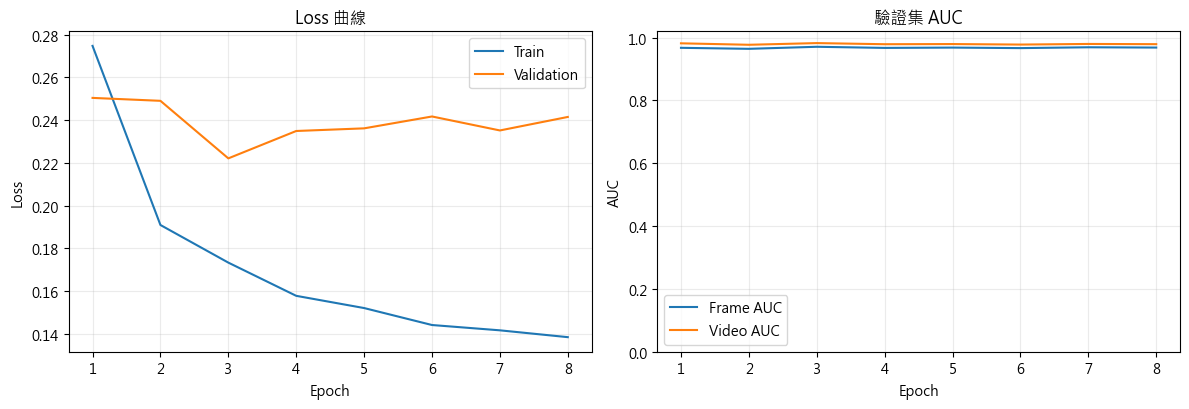

In [11]:
if HISTORY_PATH.is_file():
    history_df = pd.read_csv(HISTORY_PATH)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
    axes[0].set_title("Loss 曲線")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(
        history_df["epoch"],
        history_df["val_frame_auc"],
        label="Frame AUC",
    )
    axes[1].plot(
        history_df["epoch"],
        history_df["val_video_auc"],
        label="Video AUC",
    )
    axes[1].set_title("驗證集 AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].set_ylim(0, 1.02)
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("尚無 training_history.csv。")


## 11. 獨立測試集評估

固定載入 `best_model.pth`（第 3 個 epoch 的權重），不使用最後一個 epoch 的結果。

In [12]:
if not RUN_TEST:
    print("目前 RUN_TEST=False，尚未使用獨立測試集。")
elif SMOKE_TEST:
    raise ValueError("Smoke Test 不輸出正式測試結論。請先完成正式訓練。")
elif not BEST_MODEL_PATH.is_file():
    raise FileNotFoundError(f"找不到最佳模型：{BEST_MODEL_PATH}")
else:
    best_checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.eval()

    with torch.no_grad():
        (
            test_loss,
            test_frame_metrics,
            test_video_metrics,
            test_frame_df,
            test_video_df,
        ) = run_epoch(model, dataloaders["test"], criterion)

    test_frame_df["prediction"] = (
        test_frame_df["fake_probability"] >= 0.5
    ).astype(int)
    test_video_df["prediction"] = (
        test_video_df["fake_probability"] >= 0.5
    ).astype(int)

    test_frame_df.to_csv(
        TEST_FRAME_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    test_video_df.to_csv(
        TEST_VIDEO_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    test_results = {
        "loss": float(test_loss),
        "frame_level": test_frame_metrics,
        "video_level": test_video_metrics,
        "best_validation_video_auc": float(
            best_checkpoint["best_val_auc"]
        ),
    }
    with TEST_METRICS_PATH.open("w", encoding="utf-8") as file:
        json.dump(test_results, file, ensure_ascii=False, indent=2)

    print(json.dumps(test_results, ensure_ascii=False, indent=2))
    print("\nFrame-level Classification Report")
    print(
        classification_report(
            test_frame_df["label"],
            test_frame_df["prediction"],
            target_names=["Real", "Fake"],
            digits=4,
            zero_division=0,
        )
    )
    print("Video-level Classification Report")
    print(
        classification_report(
            test_video_df["label"],
            test_video_df["prediction"],
            target_names=["Real", "Fake"],
            digits=4,
            zero_division=0,
        )
    )


Evaluate:   0%|          | 0/140 [00:00<?, ?it/s]

{
  "loss": 0.2352697950122612,
  "frame_level": {
    "accuracy": 0.8966517857142857,
    "precision": 0.9173320807891029,
    "recall": 0.871875,
    "f1": 0.8940260929274434,
    "auc": 0.9674443957270408
  },
  "video_level": {
    "accuracy": 0.9214285714285714,
    "precision": 0.9402985074626866,
    "recall": 0.9,
    "f1": 0.9197080291970803,
    "auc": 0.9804591836734695
  },
  "best_validation_video_auc": 0.9825510204081633
}

Frame-level Classification Report
              precision    recall  f1-score   support

        Real     0.8779    0.9214    0.8992      2240
        Fake     0.9173    0.8719    0.8940      2240

    accuracy                         0.8967      4480
   macro avg     0.8976    0.8967    0.8966      4480
weighted avg     0.8976    0.8967    0.8966      4480

Video-level Classification Report
              precision    recall  f1-score   support

        Real     0.9041    0.9429    0.9231       140
        Fake     0.9403    0.9000    0.9197       140


## 12. 混淆矩陣與 ROC Curve

測試結果：frame-level AUC 0.9674、accuracy 0.8967；video-level AUC 0.9805、accuracy 0.9214。

由 16 幀平均聚合到影片層級後，accuracy 提升約 2.5 個百分點，說明單張畫面的判斷有相當的變異，多幀平均能抵銷一部分。

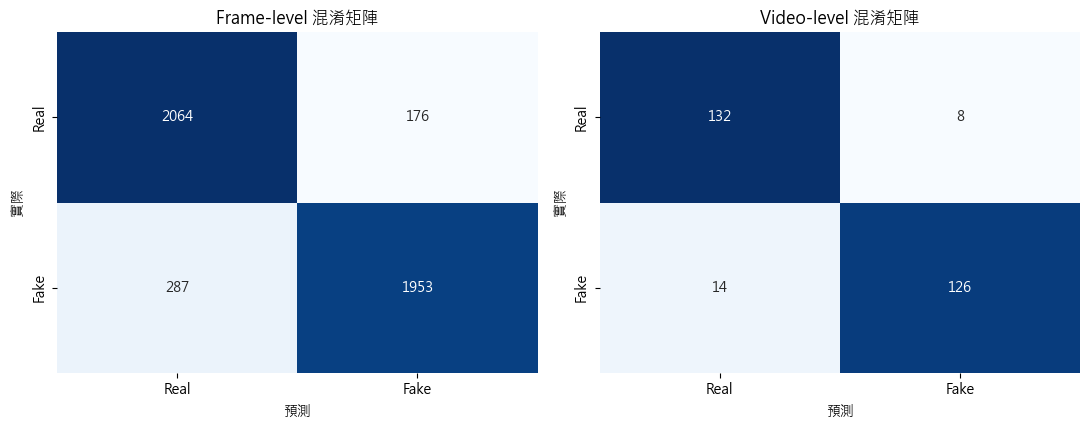

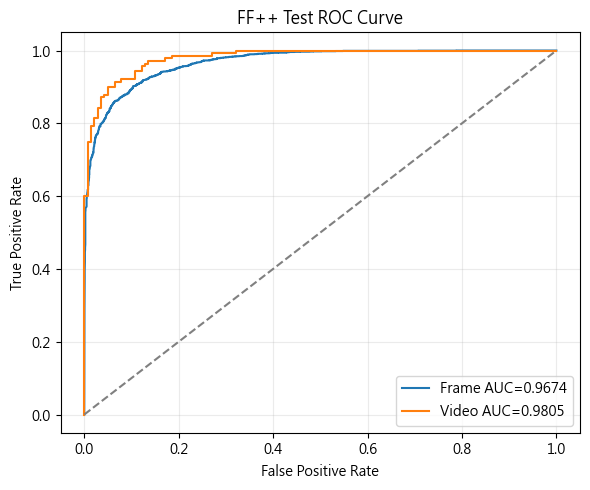

In [13]:
if "test_frame_df" not in globals():
    print("尚未執行正式測試。")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

    frame_cm = confusion_matrix(
        test_frame_df["label"],
        test_frame_df["prediction"],
        labels=[0, 1],
    )
    sns.heatmap(
        frame_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
        ax=axes[0],
    )
    axes[0].set_title("Frame-level 混淆矩陣")
    axes[0].set_xlabel("預測")
    axes[0].set_ylabel("實際")

    video_cm = confusion_matrix(
        test_video_df["label"],
        test_video_df["prediction"],
        labels=[0, 1],
    )
    sns.heatmap(
        video_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
        ax=axes[1],
    )
    axes[1].set_title("Video-level 混淆矩陣")
    axes[1].set_xlabel("預測")
    axes[1].set_ylabel("實際")

    plt.tight_layout()
    plt.show()

    fpr_frame, tpr_frame, _ = roc_curve(
        test_frame_df["label"],
        test_frame_df["fake_probability"],
    )
    fpr_video, tpr_video, _ = roc_curve(
        test_video_df["label"],
        test_video_df["fake_probability"],
    )

    plt.figure(figsize=(6, 5))
    plt.plot(
        fpr_frame,
        tpr_frame,
        label=f"Frame AUC={test_frame_metrics['auc']:.4f}",
    )
    plt.plot(
        fpr_video,
        tpr_video,
        label=f"Video AUC={test_video_metrics['auc']:.4f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("FF++ Test ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 13. 錯誤分類案例

依錯誤信心排序，列出模型最有把握但判斷錯誤的樣本，用於檢查裁臉品質、標籤正確性與模型實際依據的線索。

原本此處為誤判樣本的影像預覽，因 FaceForensics++ 授權條款限制影像再散布，已於公開版本移除。程式碼保留，可在本機重現。

In [14]:
if "test_frame_df" not in globals():
    print("尚未執行正式測試。")
else:
    errors_df = test_frame_df[
        test_frame_df["label"] != test_frame_df["prediction"]
    ].copy()
    errors_df["error_confidence"] = np.where(
        errors_df["prediction"].eq(1),
        errors_df["fake_probability"],
        1.0 - errors_df["fake_probability"],
    )
    errors_df = errors_df.sort_values(
        "error_confidence",
        ascending=False,
    )

    sample_count = min(12, len(errors_df))
    if sample_count == 0:
        print("測試集沒有錯誤分類圖片。")
    else:
        samples = errors_df.head(sample_count)
        columns = 4
        rows = math.ceil(sample_count / columns)
        fig, axes = plt.subplots(rows, columns, figsize=(12, 3 * rows))
        axes = np.array(axes).reshape(-1)

        for axis, (_, row) in zip(axes, samples.iterrows()):
            with Image.open(row["path"]) as image:
                axis.imshow(image.convert("RGB"))
            axis.set_title(
                f"實際={row['class_name']} / "
                f"P(Fake)={row['fake_probability']:.3f}"
            )
            axis.axis("off")

        for axis in axes[sample_count:]:
            axis.axis("off")

        plt.tight_layout()
        plt.show()


## 基準結果

| 層級 | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Frame | 0.8967 | 0.9173 | 0.8719 | 0.8940 | 0.9674 |
| Video | 0.9214 | 0.9403 | 0.9000 | 0.9197 | 0.9805 |

最佳驗證 video AUC 為 0.9826（第 3 epoch）。

這條線是後續兩個實驗的比較基準：05 在特徵層加入輕量 Adapter，07 改用完整 Forensics Adapter。任一方法若無法超過此處的驗證 AUC，就不能主張新增結構帶來改善。